# Household Power Consumption: Forecasting & Anomaly Detection

**Dataset:** UCI *Individual Household Electric Power Consumption*. One-minute measurements from a household in Sceaux, France (Dec 2006 to Nov 2010), expected at `data/raw/household_power_consumption.txt`.

**Target:** `energy_kwh`, the daily electricity consumption in kWh, aggregated from the minute-level `Global_active_power` readings.

**Contents**

1. Data loading & preprocessing (plus sub-metering exploration from the raw minute data)
2. Exploratory analysis & stationarity testing (ADF, ACF/PACF)
3. Decomposition (classical & STL)
4. Forecasting on a 90-day holdout, followed by a rolling-origin validation report
5. Anomaly detection (z-score, SARIMA residuals, PCA, Isolation Forest) & re-forecasting after cleaning

The notebook is self-contained. It needs only the raw data file and standard libraries (`pandas`, `numpy`, `matplotlib`, `statsmodels`, `prophet`). It can live at the project root or in a `notebooks/` subfolder, since the setup cell locates `data/raw/` automatically.

In [ ]:
# Install dependencies into the current kernel (safe to re-run; skips if already present).
%pip install -q -r requirements.txt

In [2]:
%matplotlib inline
import logging
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Prophet is chatty at INFO level; keep the notebook output readable.
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.CRITICAL)
logging.getLogger("cmdstanpy").disabled = True
from prophet import Prophet
from sklearn.ensemble import IsolationForest
plt.rcParams["figure.figsize"] = (13, 4)
pd.set_option("display.max_columns", None)

RAW_FILE = "household_power_consumption.txt"


def find_raw_data() -> Path:
    """Locate data/raw/household_power_consumption.txt from the notebook location."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "data" / "raw" / RAW_FILE
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/raw/{RAW_FILE}. Download the UCI 'Individual household "
        "electric power consumption' dataset and place it under data/raw/."
    )


RAW_PATH = find_raw_data()
print("Raw data file:", RAW_PATH)

Raw data file: F:\Project_TSA\deliverables\data\raw\household_power_consumption.txt


## 1. Data loading & preprocessing

The raw file is semicolon-separated, encodes missing values as `?`, and keeps the date and time in separate columns. We join them into a single datetime index and coerce every measurement column to numeric.

In [3]:
raw = pd.read_csv(RAW_PATH, sep=";", na_values="?", low_memory=False)
raw["datetime"] = pd.to_datetime(raw["Date"] + " " + raw["Time"], format="%d/%m/%Y %H:%M:%S")
raw = raw.drop(columns=["Date", "Time"]).set_index("datetime").sort_index()
raw = raw.apply(pd.to_numeric, errors="coerce")

print(f"Rows: {len(raw):,}")
print(f"Period: {raw.index.min()}  ->  {raw.index.max()}")
raw.isna().sum().to_frame("missing_values")

Rows: 2,075,259
Period: 2006-12-16 17:24:00  ->  2010-11-26 21:02:00


,missing_values
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


Missing values (about 1.25% of rows, mostly a handful of long outage gaps) are filled by time-based interpolation, with forward and backward fill for the edges. We then aggregate the minute-level data to a **daily** series. `Global_active_power` is in kW sampled once per minute, so daily energy is `sum(kW) / 60` kWh. Working at daily granularity keeps decomposition, SARIMA, and anomaly detection easy to interpret, and it is the level the rest of the notebook uses.

In [4]:
# Time-based interpolation for the gaps, then forward/backward fill for the edges.
clean = raw.interpolate(method="time").ffill().bfill()
print("Missing values after cleaning:", int(clean.isna().sum().sum()))

# Aggregate to daily level: readings are 1-minute kW samples, so kWh = sum(kW) / 60.
daily = pd.DataFrame(index=clean.resample("D").mean().index)
daily["energy_kwh"] = clean["Global_active_power"].resample("D").sum() / 60.0
daily["voltage_mean"] = clean["Voltage"].resample("D").mean()
daily["intensity_mean"] = clean["Global_intensity"].resample("D").mean()
# Sub-meters are recorded in Wh per minute; daily kWh = sum(Wh) / 1000.
for col, name in [
    ("Sub_metering_1", "sub_meter_kitchen_kwh"),
    ("Sub_metering_2", "sub_meter_laundry_kwh"),
    ("Sub_metering_3", "sub_meter_climate_kwh"),
]:
    daily[name] = clean[col].resample("D").sum() / 1000.0
daily["sub_meter_total_kwh"] = daily[
    ["sub_meter_kitchen_kwh", "sub_meter_laundry_kwh", "sub_meter_climate_kwh"]
].sum(axis=1)
daily["unmetered_kwh"] = daily["energy_kwh"] - daily["sub_meter_total_kwh"]
daily = daily.asfreq("D").interpolate(method="time")
target = daily["energy_kwh"]

# Cache the daily series so the modeling stages can be re-run without reparsing 2M rows.
cache_path = RAW_PATH.parents[1] / "processed" / "daily_notebook.csv"
cache_path.parent.mkdir(parents=True, exist_ok=True)
daily.to_csv(cache_path)

del raw, clean  # free memory
print(f"Daily series: {len(daily)} days ({daily.index.min().date()} -> {daily.index.max().date()})")
daily.describe().round(2)

Missing values after cleaning: 0


Daily series: 1442 days (2006-12-16 -> 2010-11-26)


,energy_kwh,voltage_mean,intensity_mean,sub_meter_kitchen_kwh,sub_meter_laundry_kwh,sub_meter_climate_kwh,sub_meter_total_kwh,unmetered_kwh
count,1442.00,1442.00,1442.00,1442.00,1442.00,1442.00,1442.00,1442.00
mean,26.15,240.83,4.63,1.60,1.86,9.27,12.72,13.43
std,10.03,2.05,1.74,1.59,2.09,3.77,5.43,6.13
min,4.17,231.09,0.81,0.00,0.00,0.00,0.00,2.31
25%,19.47,240.07,3.50,0.58,0.43,6.66,9.09,9.38
50%,25.82,240.96,4.55,1.11,0.69,9.29,12.31,12.64
75%,31.67,241.87,5.54,2.20,2.73,11.77,16.15,16.53
max,79.56,247.44,14.03,11.22,12.11,23.74,31.79,61.74


**Stage 1 result:** 2,075,259 raw rows spanning 2006-12-16 to 2010-11-26, with 25,979 missing values per measurement column before cleaning and 0 afterwards. This aggregates to a daily series of 1,442 days averaging about 26 kWh/day.

## 1b. Sub-metering exploration (from the raw minute data)

The UCI file records three sub-circuits in **Wh per minute** (kitchen; laundry and fridge; water heater and A/C). We aggregate them to daily kWh next to the total `energy_kwh`. No external data is involved, only columns already present in the raw file.

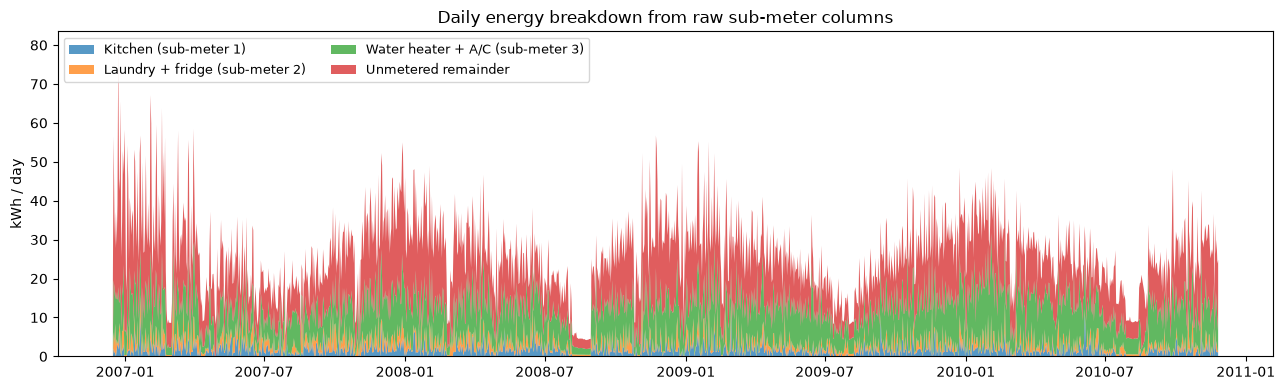

In [5]:
sub_cols = [
    "sub_meter_kitchen_kwh",
    "sub_meter_laundry_kwh",
    "sub_meter_climate_kwh",
    "unmetered_kwh",
]
labels = {
    "sub_meter_kitchen_kwh": "Kitchen (sub-meter 1)",
    "sub_meter_laundry_kwh": "Laundry + fridge (sub-meter 2)",
    "sub_meter_climate_kwh": "Water heater + A/C (sub-meter 3)",
    "unmetered_kwh": "Unmetered remainder",
}

fig, ax = plt.subplots(figsize=(13, 4))
ax.stackplot(
    daily.index,
    [daily[c].clip(lower=0) for c in sub_cols],
    labels=[labels[c] for c in sub_cols],
    alpha=0.75,
)
ax.set_title("Daily energy breakdown from raw sub-meter columns")
ax.set_ylabel("kWh / day")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

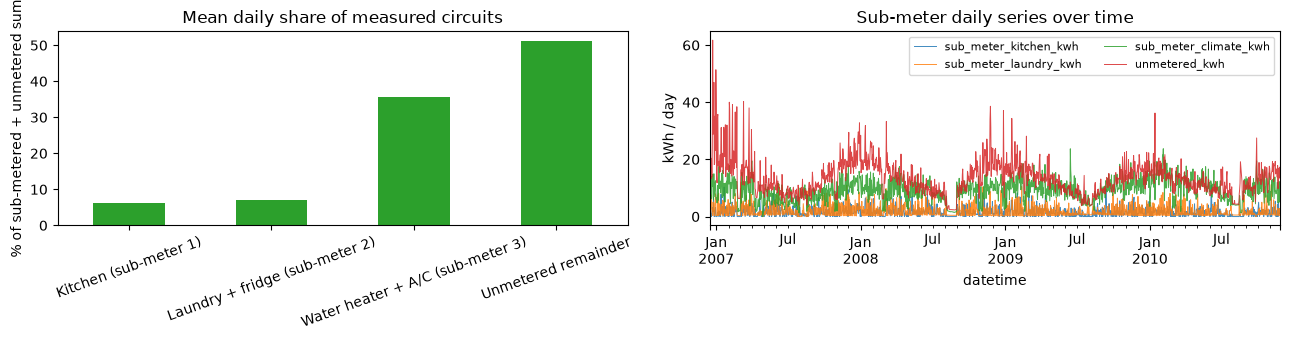

Correlation with total daily energy_kwh:
sub_meter_kitchen_kwh    0.54
sub_meter_laundry_kwh    0.48
sub_meter_climate_kwh    0.73
unmetered_kwh            0.88


,energy_kwh,sub_meter_kitchen_kwh,sub_meter_laundry_kwh,sub_meter_climate_kwh,unmetered_kwh
energy_kwh,1.00,0.54,0.48,0.73,0.88
sub_meter_kitchen_kwh,0.54,1.00,0.25,0.31,0.36
sub_meter_laundry_kwh,0.48,0.25,1.00,0.19,0.25
sub_meter_climate_kwh,0.73,0.31,0.19,1.00,0.44
unmetered_kwh,0.88,0.36,0.25,0.44,1.00


In [6]:
share = daily[sub_cols].clip(lower=0).mean()
share = share.rename(index=labels)
share_pct = (100 * share / share.sum()).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
share_pct.plot.bar(ax=axes[0], color="tab:green", rot=20)
axes[0].set_title("Mean daily share of measured circuits")
axes[0].set_ylabel("% of sub-metered + unmetered sum")
daily[sub_cols].plot(ax=axes[1], lw=0.7, alpha=0.85)
axes[1].set_title("Sub-meter daily series over time")
axes[1].set_ylabel("kWh / day")
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

corr = daily[["energy_kwh", *sub_cols]].corr().round(2)
print("Correlation with total daily energy_kwh:")
print(corr["energy_kwh"].drop("energy_kwh").to_string())
corr

**Sub-metering takeaway:** the climate circuit and the unmetered remainder track total consumption most closely (correlations of 0.73 and 0.88), while the kitchen and laundry circuits are more loosely tied to the total. The unmetered remainder is the lighting, electronics, and other loads that are not wired through the three sub-meters. These raw-derived features are useful later for interpreting anomaly flags, for example a spike in climate kWh on a day when total energy looks normal.

## 2. Exploratory analysis & stationarity

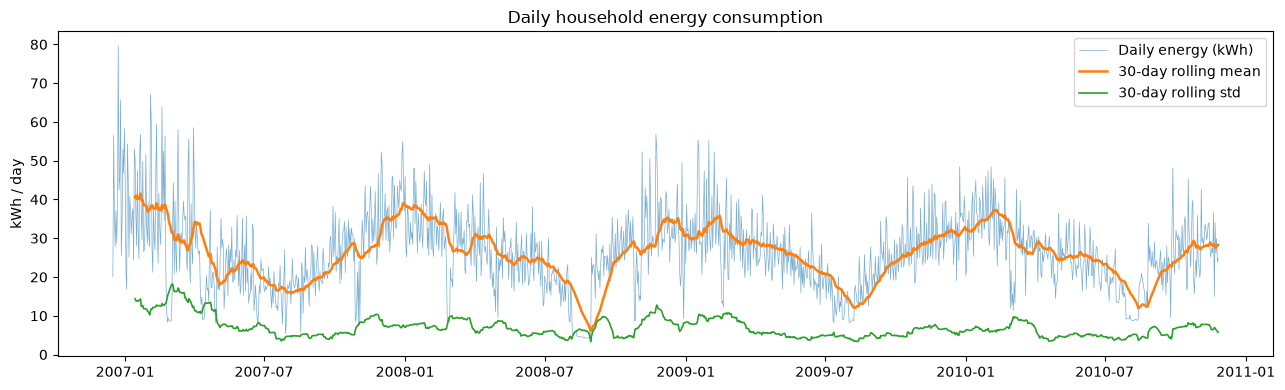

In [7]:
fig, ax = plt.subplots()
ax.plot(target, lw=0.5, alpha=0.6, label="Daily energy (kWh)")
ax.plot(target.rolling(30).mean(), lw=1.8, label="30-day rolling mean")
ax.plot(target.rolling(30).std(), lw=1.2, label="30-day rolling std")
ax.set_title("Daily household energy consumption")
ax.set_ylabel("kWh / day")
ax.legend()
plt.tight_layout()
plt.show()

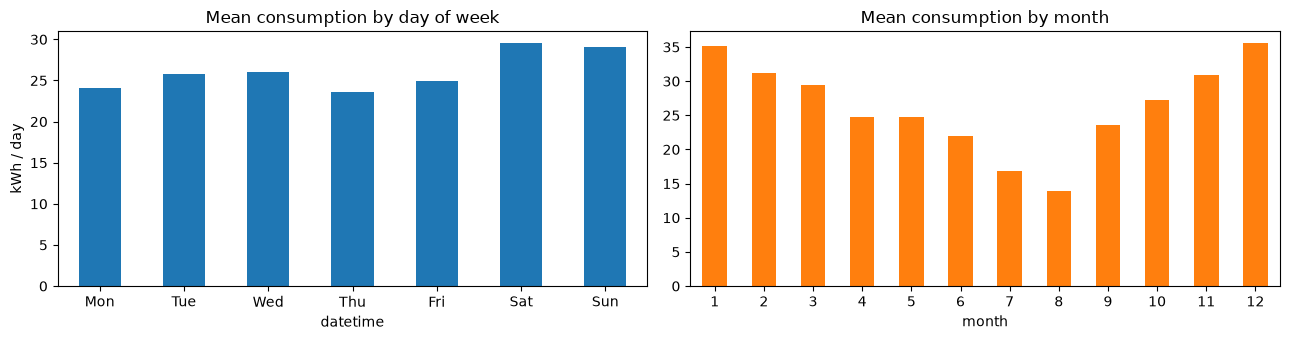

In [8]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
target.groupby(target.index.dayofweek).mean().rename(index=dict(enumerate(day_names))).plot.bar(
    ax=axes[0], color="tab:blue", rot=0)
axes[0].set_title("Mean consumption by day of week")
axes[0].set_ylabel("kWh / day")
target.groupby(target.index.month).mean().plot.bar(ax=axes[1], color="tab:orange", rot=0)
axes[1].set_title("Mean consumption by month")
axes[1].set_xlabel("month")
plt.tight_layout()
plt.show()

In [9]:
def adf_report(series: pd.Series, label: str) -> dict:
    stat, p_value, used_lags, n_obs, *_ = adfuller(series.dropna(), autolag="AIC")
    return {"series": label, "adf_statistic": round(stat, 3), "p_value": p_value,
            "used_lags": used_lags, "n_obs": n_obs, "stationary_at_5pct": p_value < 0.05}


adf_results = pd.DataFrame([
    adf_report(target, "daily energy (level)"),
    adf_report(target.diff(), "first difference"),
])
adf_results

,series,adf_statistic,p_value,used_lags,n_obs,stationary_at_5pct
0,daily energy (level),-3.710,3.972325e-03,22,1419,True
1,first difference,-10.994,6.939825e-20,21,1419,True


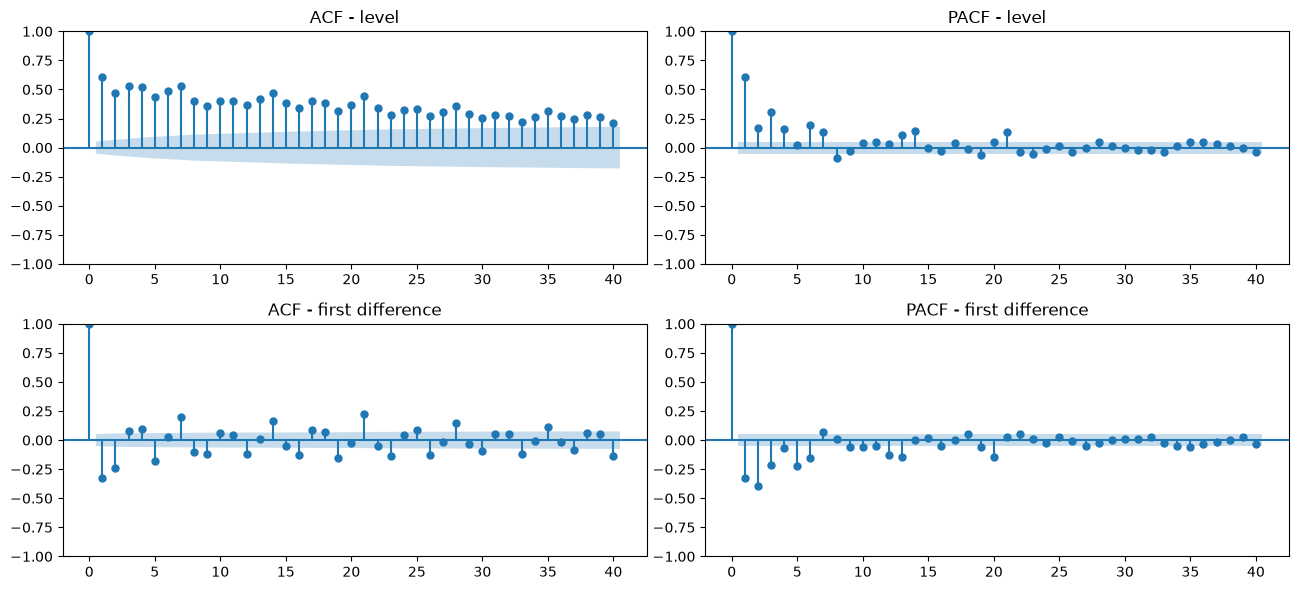

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
plot_acf(target, lags=40, ax=axes[0, 0], title="ACF - level")
plot_pacf(target, lags=40, ax=axes[0, 1], method="ywm", title="PACF - level")
plot_acf(target.diff().dropna(), lags=40, ax=axes[1, 0], title="ACF - first difference")
plot_pacf(target.diff().dropna(), lags=40, ax=axes[1, 1], method="ywm", title="PACF - first difference")
plt.tight_layout()
plt.show()

**Stage 2 findings**

- The ADF test on the daily series returns **p = 0.0040**, so we reject the unit-root null at the 5% level and treat the series as stationary in level. Consumption still swings strongly across the year (winter is roughly double summer), but that behaves like a slow, repeating cycle rather than a random walk.
- The ACF shows clear spikes at lags 7, 14, 21 and so on, and the day-of-week profile confirms weekly seasonality: weekends average about 29 kWh against 24 to 26 kWh on weekdays.
- This shapes Stage 4. We set the SARIMA seasonal period to 7 and let the differencing order `d` be chosen by information criterion instead of hardcoding it.

## 3. Decomposition: classical vs STL

Both decompositions are additive with period 7. STL runs with `robust=True` and, unlike the classical method, lets the weekly profile change gradually over time.

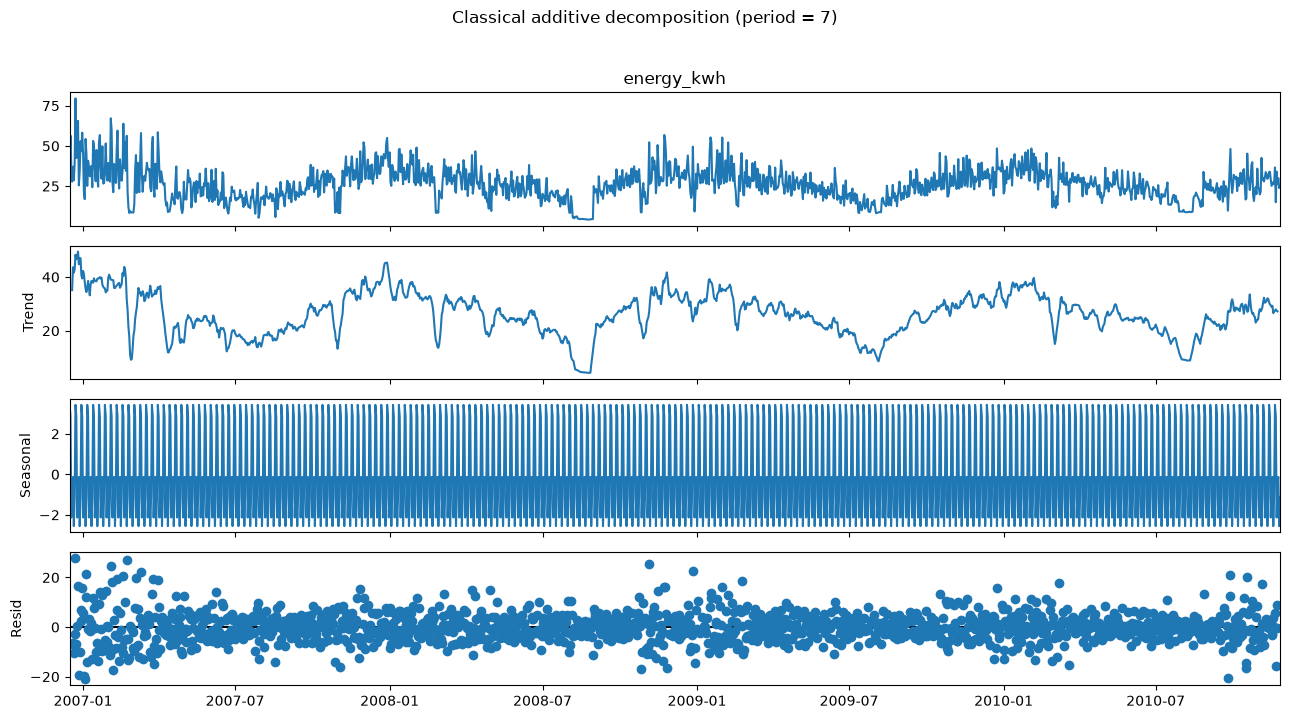

In [11]:
classical = seasonal_decompose(target, model="additive", period=7)
fig = classical.plot()
fig.set_size_inches(13, 7)
fig.suptitle("Classical additive decomposition (period = 7)", y=1.02)
plt.tight_layout()
plt.show()

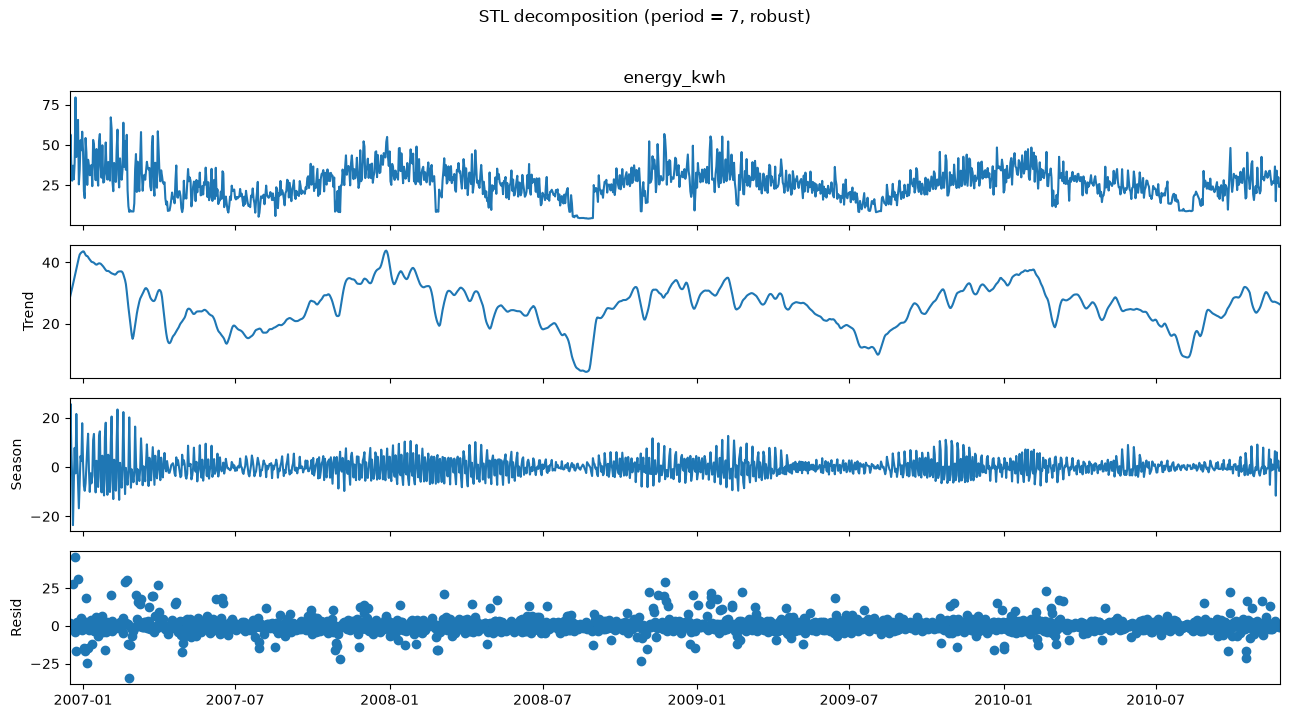

In [12]:
stl = STL(target, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(13, 7)
fig.suptitle("STL decomposition (period = 7, robust)", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
components = pd.DataFrame({
    "classical": {"trend": classical.trend.std(), "seasonal": classical.seasonal.std(),
                  "residual": classical.resid.std()},
    "STL": {"trend": stl.trend.std(), "seasonal": stl.seasonal.std(),
            "residual": stl.resid.std()},
}).round(2)
components

,classical,STL
trend,7.74,7.22
seasonal,2.15,4.21
residual,5.85,5.57


**Interpretation** (standard deviation of each component, in kWh/day): both methods agree that the slow-moving trend, which is really the annual cycle, dominates at 7.74 (classical) and 7.22 (STL). The seasonal component is much smaller at 2.15 and 4.21, and the residual sits at 5.85 and 5.57. STL assigns roughly twice as much variance to the weekly component because it lets the weekly shape drift across the four years rather than forcing one fixed profile, and its residual is correspondingly a little smaller. The weekly signal is real but modest next to trend and noise, which already hints at why beating a naive baseline in Stage 4 turns out to be hard.

## 4. Forecasting on a 90-day holdout

We use a chronological split with no shuffling: the last 90 days become the test window. The two baselines are a flat last-value naive forecast and a seasonal naive that repeats the most recent observed week.

In [14]:
TEST_SIZE = 90
SEASON = 7
train, test = target.iloc[:-TEST_SIZE], target.iloc[-TEST_SIZE:]


def rmse(actual: pd.Series, predicted: pd.Series) -> float:
    return float(np.sqrt(((actual - predicted) ** 2).mean()))


def mae(actual: pd.Series, predicted: pd.Series) -> float:
    return float((actual - predicted).abs().mean())


def mape(actual: pd.Series, predicted: pd.Series) -> float:
    """Mean absolute percentage error (%). Daily target is always > 0, but guard anyway."""
    a = np.asarray(actual, dtype=float)
    p = np.asarray(predicted, dtype=float)
    mask = a != 0
    return float(np.abs((a[mask] - p[mask]) / a[mask]).mean() * 100)


naive_fc = pd.Series(train.iloc[-1], index=test.index)
seasonal_naive_fc = pd.Series(
    np.tile(train.iloc[-SEASON:].to_numpy(), TEST_SIZE // SEASON + 1)[:TEST_SIZE],
    index=test.index,
)

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} days)")

Train: 2006-12-16 -> 2010-08-28 (1352 days)
Test:  2010-08-29 -> 2010-11-26 (90 days)


The SARIMA seasonal part is fixed to `(1, 1, 1, 7)`, one seasonal difference for the weekly pattern found in Stages 2 and 3, while `(p, d, q)` is chosen by a grid search that minimises **AIC on the training set only**. The test window plays no part in model selection, so there is no leakage.

In [15]:
SEASONAL_ORDER = (1, 1, 1, SEASON)

search_results = []
for order in product((0, 1, 2), (0, 1), (0, 1, 2)):
    try:
        fit = SARIMAX(train, order=order, seasonal_order=SEASONAL_ORDER,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        search_results.append({"order": order, "aic": fit.aic, "bic": fit.bic})
    except Exception:
        continue

search = pd.DataFrame(search_results).sort_values("aic").reset_index(drop=True)
best_order = search.loc[0, "order"]
print(f"Selected by AIC: SARIMA{best_order}x{SEASONAL_ORDER}")
search.head(5).round(1)

Selected by AIC: SARIMA(0, 1, 2)x(1, 1, 1, 7)


,order,aic,bic
0,"(0, 1, 2)",8922.2,8948.1
1,"(1, 1, 2)",8923.5,8954.7
2,"(2, 1, 2)",8924.9,8961.2
3,"(1, 0, 2)",8925.5,8956.7
4,"(2, 0, 2)",8926.2,8962.6


In [16]:
sarima_fit = SARIMAX(train, order=best_order, seasonal_order=SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_fit.forecast(steps=TEST_SIZE)
sarima_fc.index = test.index

from prophet.diagnostics import cross_validation, performance_metrics
import itertools

prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

# Prophet hyperparameter tuning grid
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []

print("Running Prophet hyperparameter tuning (this takes ~10 seconds)...")
for params in all_params:
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, 
                daily_seasonality=False, seasonality_mode="additive", **params)
    m.fit(prophet_train)
    df_cv = cross_validation(m, initial='1095 days', period='90 days', horizon='90 days', disable_tqdm=True)
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Select best parameters
best_params = all_params[np.argmin(rmses)]
print(f"Best Prophet params selected by CV: {best_params}")

# Refit Prophet with the best parameters
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                        daily_seasonality=False, seasonality_mode="additive", **best_params)
prophet_model.fit(prophet_train)

prophet_fc = pd.Series(
    prophet_model.predict(pd.DataFrame({"ds": test.index}))["yhat"].to_numpy(),
    index=test.index,
)
print("SARIMA and Prophet fitted on the training window.")

Running Prophet hyperparameter tuning (this takes ~10 seconds)...


Best Prophet params selected by CV: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.1}


SARIMA and Prophet fitted on the training window.


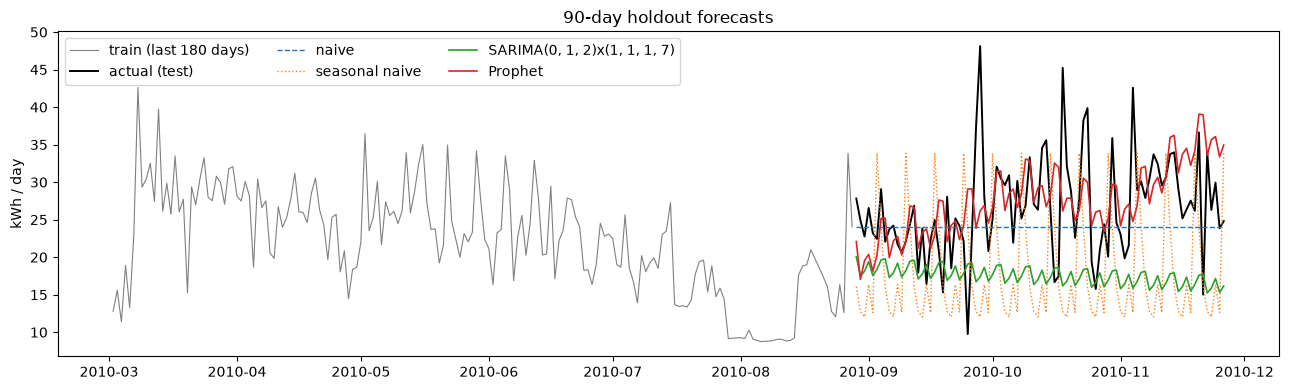

,model,rmse,mae,mape,aic,bic
0,Naive (last value),7.15,5.31,19.91,NaN,NaN
1,Seasonal naive (m=7),13.35,11.57,42.03,NaN,NaN
2,"SARIMA(0, 1, 2)x(1, 1, 1, 7)",11.48,9.62,33.36,8922.16,8948.14
3,Prophet,7.26,5.24,22.59,NaN,NaN


In [17]:
sarima_label = f"SARIMA{best_order}x{SEASONAL_ORDER}"
initial_metrics = pd.DataFrame([
    {"model": "Naive (last value)", "rmse": rmse(test, naive_fc), "mae": mae(test, naive_fc),
     "mape": mape(test, naive_fc)},
    {"model": f"Seasonal naive (m={SEASON})", "rmse": rmse(test, seasonal_naive_fc),
     "mae": mae(test, seasonal_naive_fc), "mape": mape(test, seasonal_naive_fc)},
    {"model": sarima_label, "rmse": rmse(test, sarima_fc), "mae": mae(test, sarima_fc),
     "mape": mape(test, sarima_fc), "aic": sarima_fit.aic, "bic": sarima_fit.bic},
    {"model": "Prophet", "rmse": rmse(test, prophet_fc), "mae": mae(test, prophet_fc),
     "mape": mape(test, prophet_fc)},
]).round(2)

fig, ax = plt.subplots()
ax.plot(train.iloc[-180:], lw=0.8, color="grey", label="train (last 180 days)")
ax.plot(test, lw=1.4, color="black", label="actual (test)")
ax.plot(naive_fc, lw=1.0, ls="--", label="naive")
ax.plot(seasonal_naive_fc, lw=1.0, ls=":", label="seasonal naive")
ax.plot(sarima_fc, lw=1.2, label=sarima_label)
ax.plot(prophet_fc, lw=1.2, label="Prophet")
ax.set_title("90-day holdout forecasts")
ax.set_ylabel("kWh / day")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()
initial_metrics

**Stage 4 results (test RMSE / MAE / MAPE):** naive **7.15 / 5.31 / 19.9%**, seasonal naive 13.35 / 11.57 / 42.0%, SARIMA(0,1,2)x(1,1,1,7) 11.48 / 9.62 / 33.4%, Prophet **7.26 / 5.24 / 22.6%**.

Two things stand out on this particular window:

- **Neither SARIMA nor the seasonal naive beats the flat naive baseline here**, and Prophet only matches it (better MAE, slightly worse RMSE). The test window (Sep to Nov 2010) is a steady autumn ramp-up where the last observed value is genuinely hard to improve on, and Stage 3 already showed the weekly pattern is small next to day-to-day noise, so leaning on seasonality buys little. The seasonal naive coming last confirms that a single reference week is a noisy predictor. Section 4b shows how rolling-origin validation overturns this first impression.
- AIC picks `d = 1` even though ADF rejects a unit root. AIC values are not strictly comparable across different `d`, since the likelihoods are computed on differently-differenced data. That is a known limitation of this simple grid, and we come back to it in the conclusions.

### 4a. Residual diagnostics (white-noise check)

A well-specified forecasting model should leave residuals that look like **white noise**: zero mean, constant variance, and no leftover autocorrelation. (This follows the class guidance to always check the residuals.) We look at the SARIMA training residuals four ways, with a time plot, a distribution, the residual ACF, and a normal Q-Q plot, then run the **Ljung-Box** test. Its null hypothesis is that the residuals are uncorrelated up to a given lag, so a p-value below 0.05 means some predictable structure is still there.

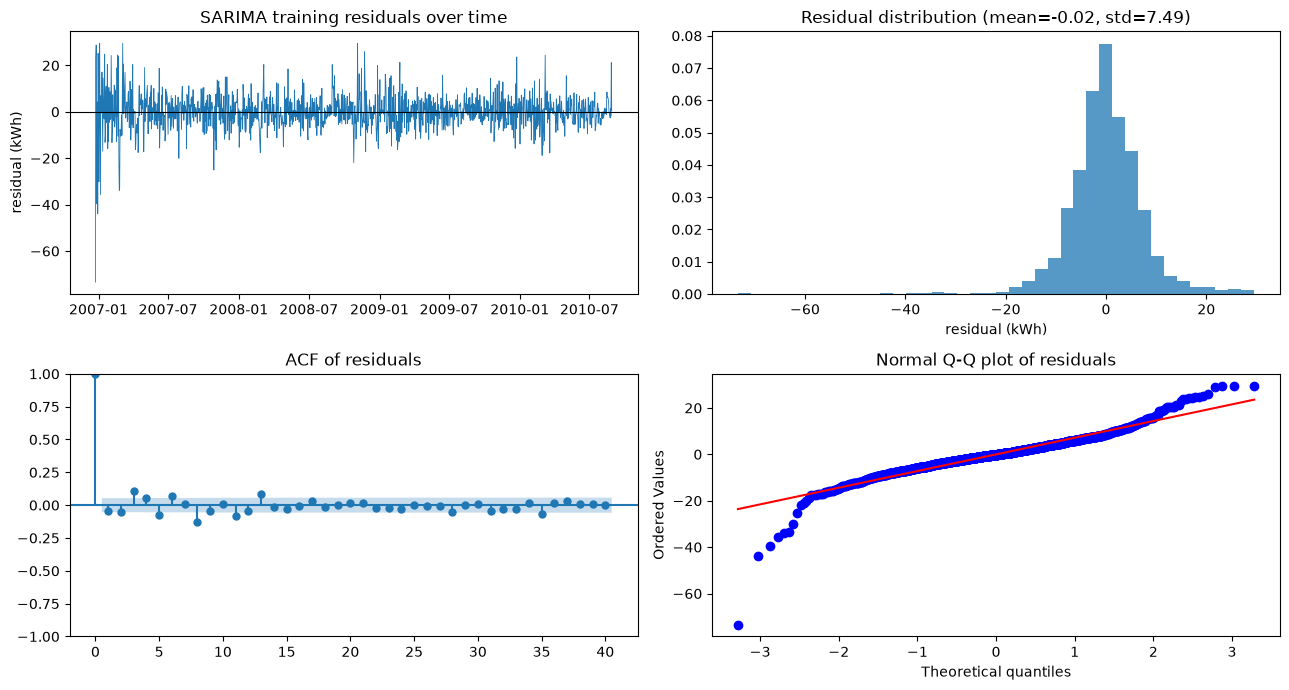

Ljung-Box test on SARIMA residuals (H0: residuals are white noise up to lag):
    lb_stat  lb_pvalue
7   40.8826        0.0
14  86.6455        0.0
21  90.3976        0.0
28  97.4158        0.0

Residual mean: -0.020 kWh (~0 expected)
Residual std:  7.491 kWh

Interpretation: smallest p-value = 0.0000 < 0.05 -> some autocorrelation remains, so there is still predictable structure the SARIMA order did not fully absorb.


In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Drop the first few differencing/seasonal warm-up residuals (diffuse initialization).
sarima_resid = sarima_fit.resid.iloc[SEASON + 1:]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0, 0].plot(sarima_resid, lw=0.6)
axes[0, 0].axhline(0, color="k", lw=0.8)
axes[0, 0].set_title("SARIMA training residuals over time")
axes[0, 0].set_ylabel("residual (kWh)")

axes[0, 1].hist(sarima_resid, bins=40, density=True, alpha=0.75, color="tab:blue")
axes[0, 1].set_title(f"Residual distribution (mean={sarima_resid.mean():.2f}, std={sarima_resid.std():.2f})")
axes[0, 1].set_xlabel("residual (kWh)")

plot_acf(sarima_resid, lags=40, ax=axes[1, 0], title="ACF of residuals")

stats.probplot(sarima_resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Normal Q-Q plot of residuals")
plt.tight_layout()
plt.show()

# Ljung-Box test at weekly-multiple lags. H0: no autocorrelation up to that lag.
lb = acorr_ljungbox(sarima_resid, lags=[7, 14, 21, 28], return_df=True)
print("Ljung-Box test on SARIMA residuals (H0: residuals are white noise up to lag):")
print(lb.round(4).to_string())
print(f"\nResidual mean: {sarima_resid.mean():.3f} kWh (~0 expected)")
print(f"Residual std:  {sarima_resid.std():.3f} kWh")
lb_min_p = float(lb['lb_pvalue'].min())
print(
    "\nInterpretation: "
    + ("all Ljung-Box p-values > 0.05 -> residuals are indistinguishable from white "
       "noise; the model captured the autocorrelation structure."
       if lb_min_p > 0.05 else
       f"smallest p-value = {lb_min_p:.4f} < 0.05 -> some autocorrelation remains, so "
       "there is still predictable structure the SARIMA order did not fully absorb.")
)

**What the diagnostics show:** the residual mean is essentially zero (about -0.02 kWh), so the model is unbiased, but every Ljung-Box p-value comes back at 0.00, so the residuals are clearly not white noise and real structure remains that the model did not absorb. This makes sense once you remember that a period-7 SARIMA can only model the weekly cycle, while the series is dominated by the annual swing (winter roughly double summer) that a weekly seasonal term cannot represent. That leftover annual structure is exactly what leaks into the residuals here, and it is the direct reason Prophet, which fits a yearly seasonality, ends up ahead of SARIMA in the validation below.

## 4b. Rolling-origin validation report

A single 90-day holdout can be fragile, so we repeat the same forecast setup on **four non-overlapping 90-day windows** stepping backward in time, with training always ending right before each test block. SARIMA reuses the `(p, d, q)` order chosen on the main training window, and Prophet is refit for each fold.

In [19]:
ORIGIN_TEST_SIZE = 90
N_FOLDS = 4
origin_results = []

for fold in range(N_FOLDS):
    test_end = len(target) - fold * ORIGIN_TEST_SIZE
    test_start = test_end - ORIGIN_TEST_SIZE
    if test_start <= ORIGIN_TEST_SIZE:
        break
    y_train = target.iloc[:test_start]
    y_test = target.iloc[test_start:test_end]

    fold_naive = pd.Series(y_train.iloc[-1], index=y_test.index)
    fold_seasonal = pd.Series(
        np.tile(y_train.iloc[-SEASON:].to_numpy(), len(y_test) // SEASON + 1)[: len(y_test)],
        index=y_test.index,
    )

    fold_sarima = SARIMAX(
        y_train,
        order=best_order,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)
    fold_sarima_fc = fold_sarima.forecast(steps=len(y_test))
    fold_sarima_fc.index = y_test.index

    fold_prophet_train = y_train.reset_index()
    fold_prophet_train.columns = ["ds", "y"]
    fold_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        **best_params
    )
    fold_prophet.fit(fold_prophet_train)
    fold_prophet_fc = pd.Series(
        fold_prophet.predict(pd.DataFrame({"ds": y_test.index}))["yhat"].to_numpy(),
        index=y_test.index,
    )

    origin_results.append(
        {
            "fold": fold + 1,
            "test_start": y_test.index.min().date(),
            "test_end": y_test.index.max().date(),
            "train_days": len(y_train),
            "naive_rmse": rmse(y_test, fold_naive),
            "seasonal_naive_rmse": rmse(y_test, fold_seasonal),
            "sarima_rmse": rmse(y_test, fold_sarima_fc),
            "prophet_rmse": rmse(y_test, fold_prophet_fc),
            "naive_mape": mape(y_test, fold_naive),
            "sarima_mape": mape(y_test, fold_sarima_fc),
            "prophet_mape": mape(y_test, fold_prophet_fc),
        }
    )

origin_report = pd.DataFrame(origin_results)
origin_summary = origin_report.drop(columns=["fold", "test_start", "test_end", "train_days"]).agg(
    ["mean", "std"]
).round(2)
origin_summary.index = ["mean_rmse", "std_rmse"]

print("Per-fold test windows:")
print(origin_report[["fold", "test_start", "test_end", "train_days", "naive_rmse", "sarima_rmse", "prophet_rmse"]].round(2).to_string(index=False))
print("\nRolling-origin RMSE summary across folds:")
print(origin_summary[["naive_rmse", "seasonal_naive_rmse", "sarima_rmse", "prophet_rmse"]].to_string())
print("\nRolling-origin MAPE (%) summary across folds:")
origin_summary[["naive_mape", "sarima_mape", "prophet_mape"]]

Per-fold test windows:
 fold test_start   test_end  train_days  naive_rmse  sarima_rmse  prophet_rmse
    1 2010-08-29 2010-11-26        1352        7.15        11.48          7.26
    2 2010-05-31 2010-08-28        1262       11.41         8.72          5.06
    3 2010-03-02 2010-05-30        1172        7.18         5.94          5.77
    4 2009-12-02 2010-03-01        1082        8.03         7.12          6.91

Rolling-origin RMSE summary across folds:
           naive_rmse  seasonal_naive_rmse  sarima_rmse  prophet_rmse
mean_rmse        8.44                10.44         8.32          6.25
std_rmse         2.02                 2.05         2.40          1.02

Rolling-origin MAPE (%) summary across folds:


,naive_mape,sarima_mape,prophet_mape
mean_rmse,34.40,32.00,20.64
std_rmse,27.88,17.49,2.88


**Rolling-origin takeaway:** the naive forecast only wins on the first fold. Averaged over the four folds, Prophet gives the best RMSE at 6.25, ahead of SARIMA at 8.32 and the naive baseline at 8.44, and the MAPE picture is the same (Prophet 20.6%, SARIMA 32.0%, naive 34.4%). Prophet is also the steadiest, with the smallest spread across folds. So the single holdout really was misleading, and the fitted models add genuine year-round value over a flat baseline.

## 5. Anomaly detection & re-forecasting

Four detectors, all calibrated on the **training window only** so the held-out test period cannot influence any threshold:

1. **Z-score** on the raw series, for global outliers.
2. **Standardised one-step-ahead SARIMA residuals**, for contextual outliers, meaning days that are unusual given the recent past and their weekly position.
3. **PCA reconstruction error** (unsupervised ML) on a small daily feature set: level, 7-day rolling mean and std, day-of-week encoding, and mean voltage and intensity.
4. **Isolation Forest** (unsupervised ML) on the same feature matrix, with contamination calibrated from the training window only.

In [20]:
# Method 1 - z-score on the raw series. Mean/std are estimated on the training
# window only, so the held-out test period does not influence the threshold.
mu, sigma = train.mean(), train.std(ddof=0)
z_scores = (target - mu) / sigma
z_flag = z_scores.abs() > 3
print(f"Z-score anomalies (|z| > 3): {int(z_flag.sum())}")

Z-score anomalies (|z| > 3): 11


In [21]:
# Method 2 - SARIMA one-step-ahead residuals: apply the train-fitted parameters to
# the full series without re-estimating, then standardize with train residual stats.
full_resid = sarima_fit.apply(target, refit=False).resid
train_resid = full_resid.loc[train.index]
resid_z = (full_resid - train_resid.mean()) / train_resid.std(ddof=0)
resid_flag = resid_z.abs() > 3
print(f"SARIMA-residual anomalies (|z| > 3): {int(resid_flag.sum())}")

SARIMA-residual anomalies (|z| > 3): 23


In [22]:
# Method 3 (unsupervised ML) - PCA reconstruction error over a small feature set.
# Components, scaling, and the 99th-percentile threshold are learned on train only.
features = pd.DataFrame(index=daily.index)
features["energy_kwh"] = target
features["rolling_7_mean"] = target.rolling(7, min_periods=3).mean()
features["rolling_7_std"] = target.rolling(7, min_periods=3).std()
features["day_of_week_sin"] = np.sin(2 * np.pi * features.index.dayofweek / 7)
features["day_of_week_cos"] = np.cos(2 * np.pi * features.index.dayofweek / 7)
features["voltage_mean"] = daily["voltage_mean"]
features["intensity_mean"] = daily["intensity_mean"]
features = features.bfill().ffill()

feat_train = features.iloc[:-TEST_SIZE]
means, stds = feat_train.mean(), feat_train.std().replace(0, 1)
x_all = ((features - means) / stds).to_numpy()
x_train = ((feat_train - means) / stds).to_numpy()

_, _, vt = np.linalg.svd(x_train, full_matrices=False)
components_pca = vt[:2]
reconstruction_error = ((x_all - x_all @ components_pca.T @ components_pca) ** 2).mean(axis=1)
threshold = np.quantile(reconstruction_error[: len(feat_train)], 0.99)
pca_flag = pd.Series(reconstruction_error > threshold, index=features.index)
print(f"PCA reconstruction-error anomalies (99th pct threshold): {int(pca_flag.sum())}")

PCA reconstruction-error anomalies (99th pct threshold): 14


In [23]:
# Method 4 (unsupervised ML) - Isolation Forest on the same feature matrix as PCA.
# contamination is set from the PCA 99th-percentile rate on train (no test peeking).
train_contamination = float(pca_flag.loc[train.index].mean())
train_contamination = min(max(train_contamination, 0.01), 0.10)

iso = IsolationForest(
    n_estimators=200,
    contamination=train_contamination,
    random_state=42,
)
iso.fit(x_train)
iso_pred = iso.predict(x_all)  # -1 = anomaly
iso_flag = pd.Series(iso_pred == -1, index=features.index)
print(f"Isolation Forest anomalies (contamination={train_contamination:.1%} on train): {int(iso_flag.sum())}")

Isolation Forest anomalies (contamination=1.0% on train): 14


z_score               11
sarima_residual       23
pca_reconstruction    14
isolation_forest      14
any_method            45
Share of days flagged by any method: 3.1%


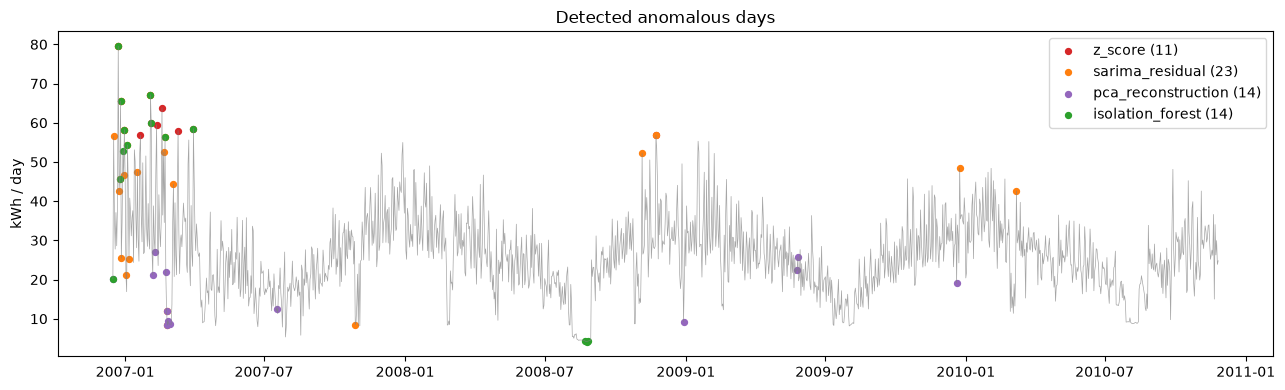

In [24]:
anomalies = pd.DataFrame({
    "z_score": z_flag,
    "sarima_residual": resid_flag,
    "pca_reconstruction": pca_flag,
    "isolation_forest": iso_flag,
})
anomalies["any_method"] = anomalies.any(axis=1)
print(anomalies.sum().to_string())
print(f"Share of days flagged by any method: {anomalies['any_method'].mean():.1%}")

fig, ax = plt.subplots()
ax.plot(target, lw=0.5, color="grey", alpha=0.7)
for method, color in [("z_score", "tab:red"), ("sarima_residual", "tab:orange"),
                      ("pca_reconstruction", "tab:purple"),
                      ("isolation_forest", "tab:green")]:
    days = target[anomalies[method]]
    ax.scatter(days.index, days.values, s=18, color=color, label=f"{method} ({len(days)})")
ax.set_title("Detected anomalous days")
ax.set_ylabel("kWh / day")
ax.legend()
plt.tight_layout()
plt.show()

Days flagged by any method inside the **training window** are replaced by time interpolation. The test window is left untouched so the before and after forecast metrics stay comparable.

In [25]:
flagged_train_days = anomalies.loc[train.index, "any_method"]
train_clean = train.copy()
train_clean[flagged_train_days] = np.nan
train_clean = train_clean.interpolate(method="time").ffill().bfill()
print(f"Interpolated over {int(flagged_train_days.sum())} anomalous training days "
      f"({flagged_train_days.mean():.1%} of the training window). Test window left untouched.")

Interpolated over 45 anomalous training days (3.3% of the training window). Test window left untouched.


In [26]:
sarima_clean_fit = SARIMAX(train_clean, order=best_order, seasonal_order=SEASONAL_ORDER,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_clean_fc = sarima_clean_fit.forecast(steps=TEST_SIZE)
sarima_clean_fc.index = test.index

prophet_clean_train = train_clean.reset_index()
prophet_clean_train.columns = ["ds", "y"]
prophet_clean = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                        daily_seasonality=False, seasonality_mode="additive", **best_params)
prophet_clean.fit(prophet_clean_train)
prophet_clean_fc = pd.Series(
    prophet_clean.predict(pd.DataFrame({"ds": test.index}))["yhat"].to_numpy(),
    index=test.index,
)

before_after = pd.DataFrame([
    {"model": sarima_label,
     "rmse_before": rmse(test, sarima_fc), "rmse_after": rmse(test, sarima_clean_fc),
     "mae_before": mae(test, sarima_fc), "mae_after": mae(test, sarima_clean_fc),
     "mape_before": mape(test, sarima_fc), "mape_after": mape(test, sarima_clean_fc)},
    {"model": "Prophet",
     "rmse_before": rmse(test, prophet_fc), "rmse_after": rmse(test, prophet_clean_fc),
     "mae_before": mae(test, prophet_fc), "mae_after": mae(test, prophet_clean_fc),
     "mape_before": mape(test, prophet_fc), "mape_after": mape(test, prophet_clean_fc)},
]).round(2)
before_after

,model,rmse_before,rmse_after,mae_before,mae_after,mape_before,mape_after
0,"SARIMA(0, 1, 2)x(1, 1, 1, 7)",11.48,10.90,9.62,9.01,33.36,31.33
1,Prophet,7.26,7.15,5.24,5.15,22.59,22.09


**Stage 5 results:** the printed flag counts show partial overlap between the four detectors. The residual-based method catches contextual spikes, the z-score catches only the global extremes, and the two ML methods also react to unusual voltage and intensity combinations. `any_method` takes the union of all four detectors on the training window only.

Re-forecasting after cleaning improves both models on the untouched test window (see the before and after table). The gain is small but consistent, which fits the idea that the flagged days were mildly distorting the fitted trend and seasonal structure.

**Summary.** Daily household consumption over 1,442 days is level-stationary by the ADF test but dominated by a slow annual cycle with a modest weekly pattern on top. On the first 90-day holdout, Prophet (RMSE 7.26) essentially ties the flat naive baseline (7.15). Rolling-origin validation shows that tie was a quirk of that one window: across four non-overlapping folds Prophet averages an RMSE of 6.25 and SARIMA 8.32, both ahead of the naive baseline at 8.44. The residual diagnostics explain why Prophet leads. SARIMA's residuals fail the Ljung-Box white-noise test (p = 0.00 at every lag) because a period-7 model cannot represent the dominant annual cycle, whereas Prophet models that yearly seasonality directly. Finally, cleaning 45 anomalous days flagged by the four train-calibrated detectors nudges both models a little further without touching the test data (SARIMA improves from 11.48 to 10.90 RMSE).